# Impact of $A$ on dipole + $m_5$ map study

The goal of this notebook is to study the impact of A on the injected dipole measurement when the $m_5$ is added.

In [1]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
%matplotlib inline
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.table import Table
import fitsio

from simulMap import *
from fitMap import *
from utile_fitsFile import *
from lumMag_sampling import *
from mappers import CountMapper, DepthMapper
from spectra import Spectrum

In [2]:
#resolution:
nside = 64
npix = hp.nside2npix(nside)
print("Number of pixels = {}".format(npix))

#sources:
NSource_px_th = int(1e6)
print("Total number of sources in the entire sky : {}".format(NSource_px_th*npix))
print("Theorical number of sources in one pixel : {}".format(NSource_px_th))

Number of pixels = 49152
Total number of sources in the entire sky : 49152000000
Theorical number of sources in one pixel : 1000000


## Study without clustering

In [3]:
DIR = "Fit_m5/m5_Dipole/m5_Dipole_"
sufix = "Param_study_NoCluster"
outputfile = DIR + sufix +".fits"

data2 = fitsio.FITS(outputfile)
data2


  file: Fit_m5/m5_Dipole/m5_Dipole_Param_study_NoCluster.fits
  mode: READONLY
  extnum hdutype         hduname[v]
  0      IMAGE_HDU       
  1      BINARY_TBL      A_STUDY

In [4]:
band = "u"

dfMinuit_data2 = Table(data2['A_STUDY'].read())
mask = dfMinuit_data2["BAND"] == band
dfMinuit_filtered = dfMinuit_data2[mask]
dfMinuit_filtered

Map_ID,N*,N*_init,N*_err,N*_fixed,N*_limit_0,N*_limit_1,A,A_init,A_err,A_fixed,A_limit_0,A_limit_1,ra,ra_init,ra_err,ra_fixed,ra_limit_0,ra_limit_1,dec,dec_init,dec_err,dec_fixed,dec_limit_0,dec_limit_1,valid,Nth_ID,Ratio_ID,BAND,N*_true,A_true,ra_true,dec_true
str3,float64,float64,float64,bool,float64,float64,float64,float64,float64,bool,float64,float64,float64,float64,float64,bool,float64,float64,float64,float64,float64,bool,float64,float64,bool,str26,str26,str1,int64,float64,int64,int64
NaN,1000001.17640465,1000000.0,8.84422117844224,False,0.0,inf,0.0009792510871929937,1.0,1.013966125444426e-05,False,0.0,1.0,168.6171078711164,100.0,0.5737398941851808,False,0.0,360.0,-5.491686082480399,0.0,0.96086761179374,False,-90.0,90.0,True,01KSAFJYRKG5T71B608D7E8YW0,01KS86Z9ZVNDZJB0VA9VVNCNJB,u,1000000,0.001,168,-7
NaN,1000001.166574354,1000000.0,8.845474200090393,False,0.0,inf,0.0010777559834522364,1.0,1.0149335318304252e-05,False,0.0,1.0,168.56084039782047,100.0,0.5214329836843206,False,0.0,360.0,-5.6304180009630596,0.0,0.8728909114319934,False,-90.0,90.0,True,01KSAFJYRKG5T71B608D7E8YW0,01KS86Z9ZVNDZJB0VA9VVNCNJB,u,1000000,0.0010985411419875584,168,-7
NaN,1000001.1630836813,1000000.0,8.844077962450683,False,0.0,inf,0.0011859676797606503,1.0,1.015714257748292e-05,False,0.0,1.0,168.50990914820957,100.0,0.4739747904357756,False,0.0,360.0,-5.755514335748471,0.0,0.7928617990075884,False,-90.0,90.0,True,01KSAFJYRKG5T71B608D7E8YW0,01KS86Z9ZVNDZJB0VA9VVNCNJB,u,1000000,0.0012067926406393288,168,-7
NaN,1000001.1645899457,1000000.0,8.845225467928685,False,0.0,inf,0.0013048591758811259,1.0,1.016529552817834e-05,False,0.0,1.0,168.4634066942663,100.0,0.4308834775619488,False,0.0,360.0,-5.868516910678828,0.0,0.72052749593538,False,-90.0,90.0,True,01KSAFJYRKG5T71B608D7E8YW0,01KS86Z9ZVNDZJB0VA9VVNCNJB,u,1000000,0.0013257113655901094,168,-7
NaN,1000001.1653929364,1000000.0,8.845108349923976,False,0.0,inf,0.001435467070166241,1.0,1.017232271793237e-05,False,0.0,1.0,168.420999805192,100.0,0.39176141398303344,False,0.0,360.0,-5.971510042864155,0.0,0.6547942093210768,False,-90.0,90.0,True,01KSAFJYRKG5T71B608D7E8YW0,01KS86Z9ZVNDZJB0VA9VVNCNJB,u,1000000,0.0014563484775012444,168,-7
NaN,1000001.1678826268,1000000.0,8.844119698391296,False,0.0,inf,0.0015789654583955237,1.0,1.0178364472279515e-05,False,0.0,1.0,168.38296424769473,100.0,0.3562309962476178,False,0.0,360.0,-6.065032108681973,0.0,0.5950779196504294,False,-90.0,90.0,True,01KSAFJYRKG5T71B608D7E8YW0,01KS86Z9ZVNDZJB0VA9VVNCNJB,u,1000000,0.0015998587196060573,168,-7
NaN,1000001.1623827181,1000000.0,8.84491822682321,False,0.0,inf,0.0017365818796905728,1.0,1.0184770006862521e-05,False,0.0,1.0,168.3483846406093,100.0,0.323953339609389,False,0.0,360.0,-6.150029102060622,0.0,0.5410067537688672,False,-90.0,90.0,True,01KSAFJYRKG5T71B608D7E8YW0,01KS86Z9ZVNDZJB0VA9VVNCNJB,u,1000000,0.0017575106248547913,168,-7
NaN,1000001.1683721263,1000000.0,8.844101872527972,False,0.0,inf,0.0019097474976093767,1.0,1.0189950747351798e-05,False,0.0,1.0,168.3168556422441,100.0,0.29462962280547345,False,0.0,360.0,-6.226356610300608,0.0,0.4918092702027006,False,-90.0,90.0,True,01KSAFJYRKG5T71B608D7E8YW0,01KS86Z9ZVNDZJB0VA9VVNCNJB,u,1000000,0.0019306977288832496,168,-7
NaN,1000001.162651138,1000000.0,8.844081679242663,False,0.0,inf,0.002099998174347842,1.0,1.0195049012868369e-05,False,0.0,1.0,168.28905676692213,100.0,0.2679794715128452,False,0.0,360.0,-6.2974044491783046,0.0,0.44717727256359785,False,-90.0,90.0,True,01KSAFJYRKG5T71B608D7E8YW0,01KS86Z9ZVNDZJB0VA9VVNCNJB,u,1000000,0.0021209508879201904,168,-7


Saving m5_A_study_val_NoCluster_band_u in Simul_Figures/Simul_Magnitude/Simul_Magnitude_ParamStudy/Simul_Magnitude_ParamStudy_NoCluster/Simul_Magnitude_ParamStudy_NoCluster_band_u/m5_A_study_val_NoCluster_band_u.pdf


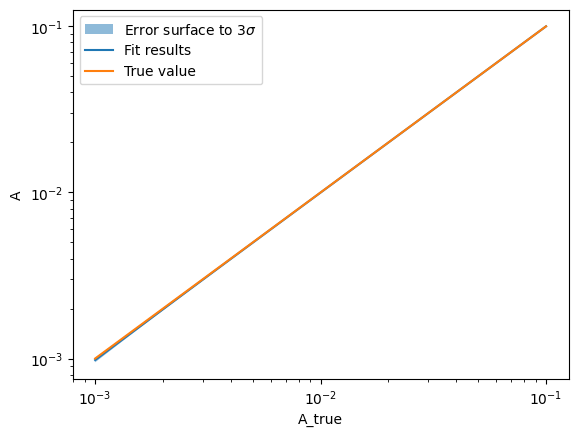

In [5]:
compareFit_val(dfMinuit_filtered, "A", "A", yscale='log', nsigma=3)
clSuffix_NoClust = f"NoCluster_band_{band}"
output_path = "Simul_Figures/Simul_Magnitude/Simul_Magnitude_ParamStudy/"
output_path_NoClust = f"{output_path}Simul_Magnitude_ParamStudy_NoCluster/Simul_Magnitude_ParamStudy_{clSuffix_NoClust}/"
sufix = f"m5_A_study_val_{clSuffix_NoClust}"
get_savefig(plt, output_path_NoClust, sufix)

Saving m5_A_study_err_NoCluster_band_u in Simul_Figures/Simul_Magnitude/Simul_Magnitude_ParamStudy/Simul_Magnitude_ParamStudy_NoCluster/Simul_Magnitude_ParamStudy_NoCluster_band_u/m5_A_study_err_NoCluster_band_u.pdf


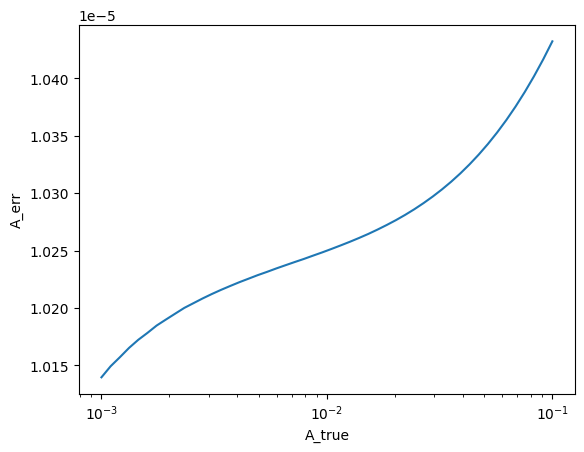

In [6]:
plt.plot(dfMinuit_filtered["A_true"], dfMinuit_filtered["A_err"], label="Fit error")
plt.xlabel('A_true')
plt.ylabel('A_err')
plt.xscale('log');

sufix = f"m5_A_study_err_{clSuffix_NoClust}"
get_savefig(plt, output_path_NoClust, sufix)

Saving m5_A_study_diff_NoCluster_band_u in Simul_Figures/Simul_Magnitude/Simul_Magnitude_ParamStudy/Simul_Magnitude_ParamStudy_NoCluster/Simul_Magnitude_ParamStudy_NoCluster_band_u/m5_A_study_diff_NoCluster_band_u.pdf


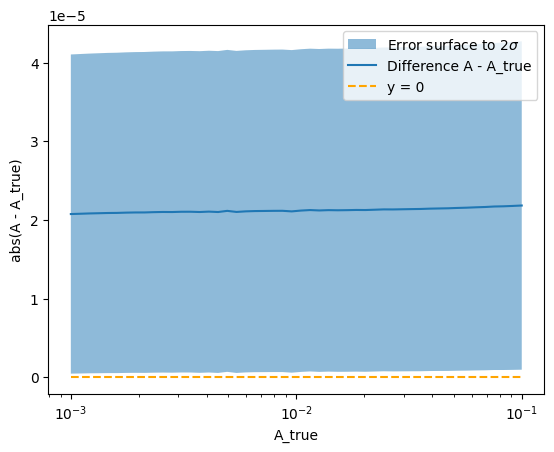

In [7]:
compareFit_diff(dfMinuit_filtered, "A", "A", nsigma=2)
sufix = f"m5_A_study_diff_{clSuffix_NoClust}"
get_savefig(plt, output_path_NoClust, sufix)

Saving m5_A_study_valRA_NoCluster_band_u in Simul_Figures/Simul_Magnitude/Simul_Magnitude_ParamStudy/Simul_Magnitude_ParamStudy_NoCluster/Simul_Magnitude_ParamStudy_NoCluster_band_u/m5_A_study_valRA_NoCluster_band_u.pdf


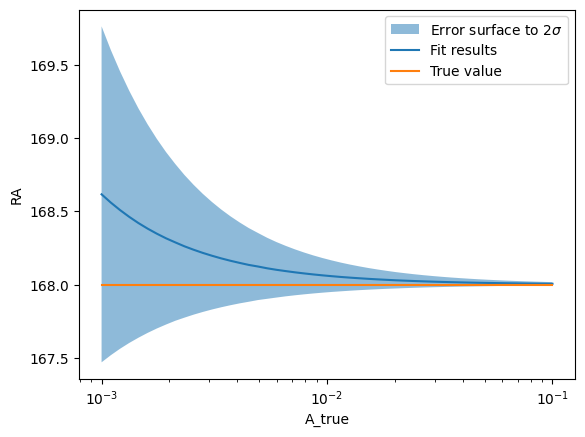

In [8]:
compareFit_val(dfMinuit_filtered, "A", "ra", ylabel="RA", nsigma=2)

sufix = f"m5_A_study_valRA_{clSuffix_NoClust}"
get_savefig(plt, output_path_NoClust, sufix)

Saving m5_A_study_diffRA_NoCluster_band_u in Simul_Figures/Simul_Magnitude/Simul_Magnitude_ParamStudy/Simul_Magnitude_ParamStudy_NoCluster/Simul_Magnitude_ParamStudy_NoCluster_band_u/m5_A_study_diffRA_NoCluster_band_u.pdf


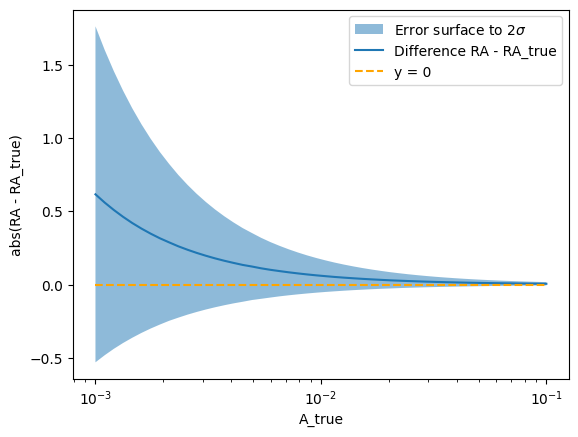

In [9]:
compareFit_diff(dfMinuit_filtered, "A", "ra", ylegend="RA", nsigma=2)

sufix = f"m5_A_study_diffRA_{clSuffix_NoClust}"
get_savefig(plt, output_path_NoClust, sufix)

Saving m5_A_study_valDEC_NoCluster_band_u in Simul_Figures/Simul_Magnitude/Simul_Magnitude_ParamStudy/Simul_Magnitude_ParamStudy_NoCluster/Simul_Magnitude_ParamStudy_NoCluster_band_u/m5_A_study_valDEC_NoCluster_band_u.pdf


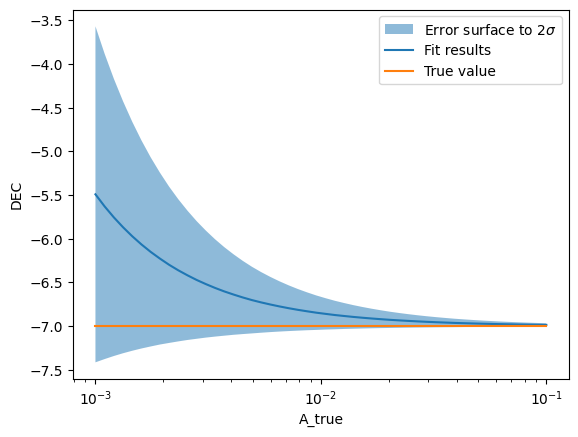

In [10]:
compareFit_val(dfMinuit_filtered, "A", "dec", ylabel="DEC", nsigma=2)

sufix = f"m5_A_study_valDEC_{clSuffix_NoClust}"
get_savefig(plt, output_path_NoClust, sufix)

Saving m5_A_study_diffDEC_NoCluster_band_u in Simul_Figures/Simul_Magnitude/Simul_Magnitude_ParamStudy/Simul_Magnitude_ParamStudy_NoCluster/Simul_Magnitude_ParamStudy_NoCluster_band_u/m5_A_study_diffDEC_NoCluster_band_u.pdf


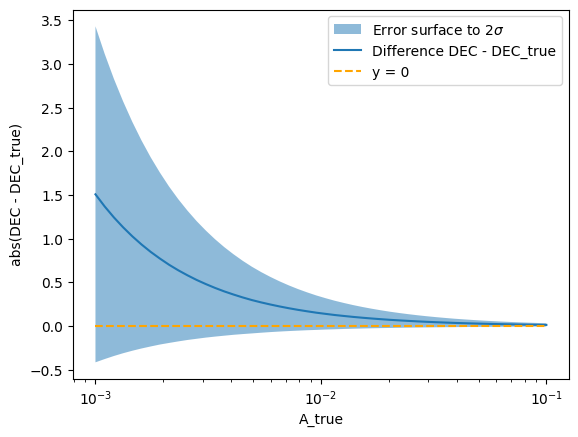

In [11]:
compareFit_diff(dfMinuit_filtered, "A", "dec", ylegend="DEC", nsigma=2)

sufix = f"m5_A_study_diffDEC_{clSuffix_NoClust}"
get_savefig(plt, output_path_NoClust, sufix)

Saving m5_A_study_diffARaDec_NoCluster_band_u in Simul_Figures/Simul_Magnitude/Simul_Magnitude_ParamStudy/Simul_Magnitude_ParamStudy_NoCluster/Simul_Magnitude_ParamStudy_NoCluster_band_u/m5_A_study_diffARaDec_NoCluster_band_u.pdf


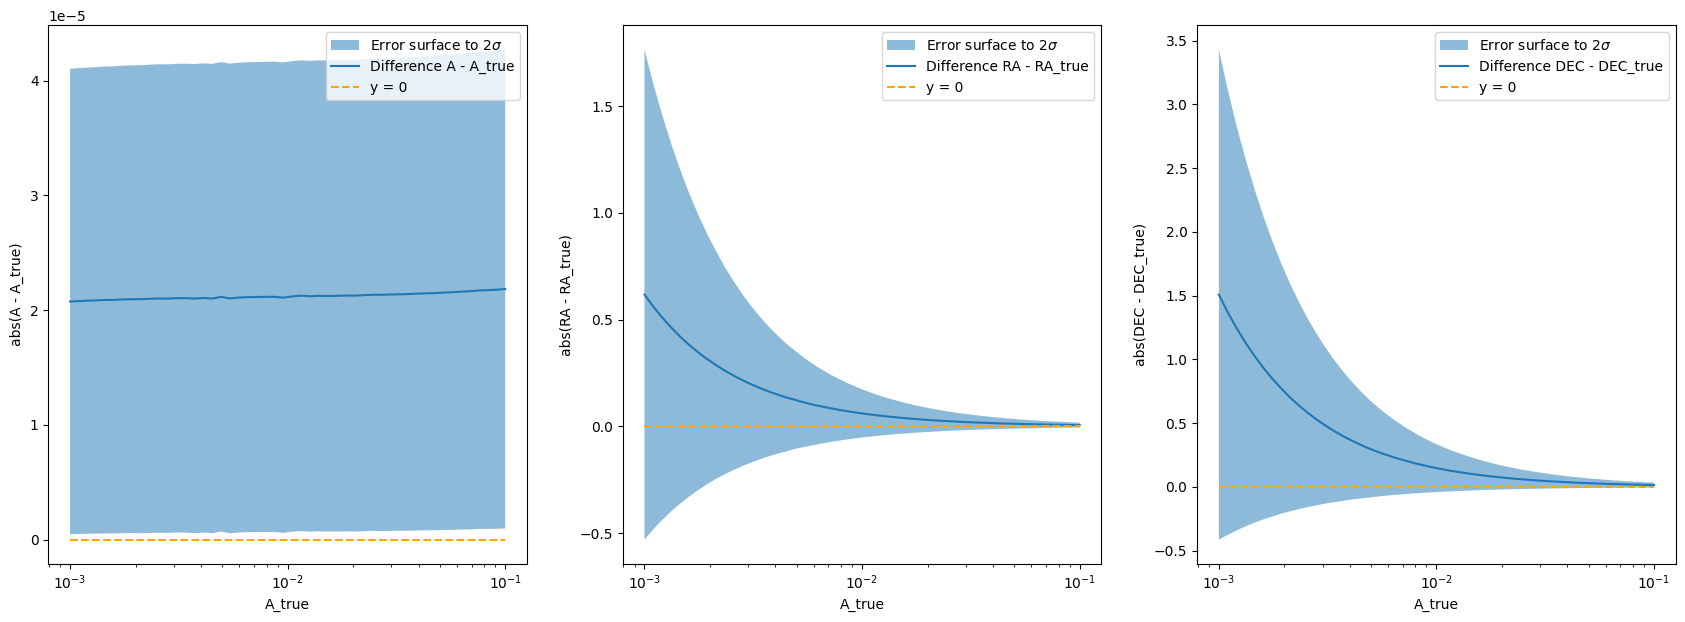

In [12]:
fig, ax = plt.subplots(1, 3, figsize=(3*7,7))
compareFit_diff(dfMinuit_filtered, "A", "A", nsigma=2, figax=(fig, ax[0]))
compareFit_diff(dfMinuit_filtered, "A", "ra", ylegend="RA", nsigma=2, figax=(fig, ax[1]))
compareFit_diff(dfMinuit_filtered, "A", "dec", ylegend="DEC", nsigma=2, figax=(fig, ax[2]))

sufix = f"m5_A_study_diffARaDec_{clSuffix_NoClust}"
get_savefig(plt, output_path_NoClust, sufix)

Saving m5_A_study_ratioARaDec_NoCluster_band_u in Simul_Figures/Simul_Magnitude/Simul_Magnitude_ParamStudy/Simul_Magnitude_ParamStudy_NoCluster/Simul_Magnitude_ParamStudy_NoCluster_band_u/m5_A_study_ratioARaDec_NoCluster_band_u.pdf


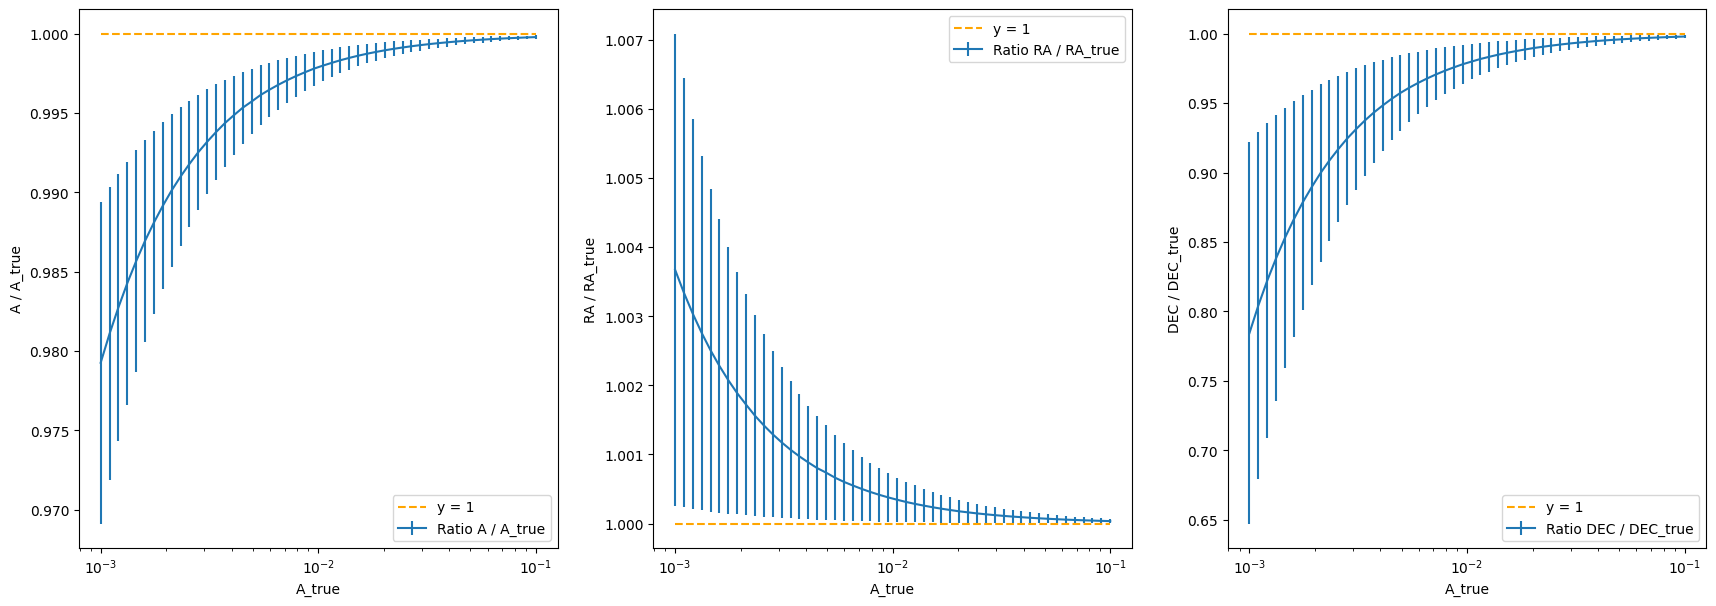

In [13]:
fig, ax = plt.subplots(1, 3, figsize=(3*7,7))
compareFit_ratio(dfMinuit_filtered, "A", "A", nsigma=2, figax=(fig, ax[0]), surface=False)
compareFit_ratio(dfMinuit_filtered, "A", "ra", ylegend="RA", nsigma=2, figax=(fig, ax[1]), surface=False)
compareFit_ratio(dfMinuit_filtered, "A", "dec", ylegend="DEC", nsigma=2, figax=(fig, ax[2]), surface=False)
ax[0].legend(loc="lower right")
ax[2].legend(loc="lower right")

sufix = f"m5_A_study_ratioARaDec_{clSuffix_NoClust}"
get_savefig(plt, output_path_NoClust, sufix)

## Study with clustering

In [14]:
DIR = "Fit_m5/m5_Dipole/m5_Dipole_"
sufix = "Param_study_Cluster"
outputfile = DIR + sufix +".fits"

data3 = fitsio.FITS(outputfile)
data3


  file: Fit_m5/m5_Dipole/m5_Dipole_Param_study_Cluster.fits
  mode: READONLY
  extnum hdutype         hduname[v]
  0      IMAGE_HDU       
  1      BINARY_TBL      A_STUDY

In [15]:
dfMinuit_data3 = Table(data3['A_STUDY'].read())
mask = dfMinuit_data3["BAND"] == band
dfMinuit_filtered = dfMinuit_data3[mask]
dfMinuit_filtered

Map_ID,N*,N*_init,N*_err,N*_fixed,N*_limit_0,N*_limit_1,A,A_init,A_err,A_fixed,A_limit_0,A_limit_1,ra,ra_init,ra_err,ra_fixed,ra_limit_0,ra_limit_1,dec,dec_init,dec_err,dec_fixed,dec_limit_0,dec_limit_1,valid,Nth_ID,Ratio_ID,BAND,Cluster_ID,N*_true,A_true,ra_true,dec_true
str3,float64,float64,float64,bool,float64,float64,float64,float64,float64,bool,float64,float64,float64,float64,float64,bool,float64,float64,float64,float64,float64,bool,float64,float64,bool,str26,str26,str1,str26,int64,float64,int64,int64
NaN,997987.7859372935,1000000.0,8.831137966713868,False,0.0,inf,0.0018134166658925568,1.0,1.0409664360113e-05,False,0.0,1.0,190.49942571444876,100.0,0.33512697456093576,False,0.0,360.0,23.899884226138013,0.0,0.5150729213731182,False,-90.0,90.0,True,01KSAFJYRKG5T71B608D7E8YW0,01KS86Z9ZVNDZJB0VA9VVNCNJB,u,01KS35MHF6K03WWH0EBCDSQJ4K,1000000,0.001,168,-7
NaN,997987.8817424926,1000000.0,8.83146730903536,False,0.0,inf,0.0018925305482702685,1.0,1.0298472591686435e-05,False,0.0,1.0,189.26935514671976,100.0,0.3177499183367729,False,0.0,360.0,22.45437589818181,0.0,0.49565546009126926,False,-90.0,90.0,True,01KSAFJYRKG5T71B608D7E8YW0,01KS86Z9ZVNDZJB0VA9VVNCNJB,u,01KS35MHF6K03WWH0EBCDSQJ4K,1000000,0.0010985411419875584,168,-7
NaN,997987.8471096883,1000000.0,8.759910687804222,False,0.0,inf,0.001981470536776755,1.0,1.0156586466746574e-05,False,0.0,1.0,188.0575923751327,100.0,0.30043774418220437,False,0.0,360.0,20.979041403883354,0.0,0.4712665641057736,False,-90.0,90.0,True,01KSAFJYRKG5T71B608D7E8YW0,01KS86Z9ZVNDZJB0VA9VVNCNJB,u,01KS35MHF6K03WWH0EBCDSQJ4K,1000000,0.0012067926406393288,168,-7
NaN,997987.7970290616,1000000.0,8.832339193788357,False,0.0,inf,0.002081308323486997,1.0,1.0099112055763932e-05,False,0.0,1.0,186.87246303383344,100.0,0.2834478123811124,False,0.0,360.0,19.504708144105273,0.0,0.4540833815789327,False,-90.0,90.0,True,01KSAFJYRKG5T71B608D7E8YW0,01KS86Z9ZVNDZJB0VA9VVNCNJB,u,01KS35MHF6K03WWH0EBCDSQJ4K,1000000,0.0013257113655901094,168,-7
NaN,997987.8580830338,1000000.0,8.832621143432334,False,0.0,inf,0.0021933102707864948,1.0,1.0014314293593785e-05,False,0.0,1.0,185.71596858197,100.0,0.26671169144364626,False,0.0,360.0,18.032447977116757,0.0,0.4322266349295525,False,-90.0,90.0,True,01KSAFJYRKG5T71B608D7E8YW0,01KS86Z9ZVNDZJB0VA9VVNCNJB,u,01KS35MHF6K03WWH0EBCDSQJ4K,1000000,0.0014563484775012444,168,-7
NaN,997987.7782347717,1000000.0,8.832945489673875,False,0.0,inf,0.0023186252733454335,1.0,9.94011312390841e-06,False,0.0,1.0,184.5956555432784,100.0,0.25038130503362765,False,0.0,360.0,16.57268717806726,0.0,0.4099524798167433,False,-90.0,90.0,True,01KSAFJYRKG5T71B608D7E8YW0,01KS86Z9ZVNDZJB0VA9VVNCNJB,u,01KS35MHF6K03WWH0EBCDSQJ4K,1000000,0.0015998587196060573,168,-7
NaN,997987.8302784342,1000000.0,8.83343712426722,False,0.0,inf,0.0024587297833345402,1.0,9.877453752984771e-06,False,0.0,1.0,183.5152239628753,100.0,0.23451856405228,False,0.0,360.0,15.13727865122852,0.0,0.387458178238834,False,-90.0,90.0,True,01KSAFJYRKG5T71B608D7E8YW0,01KS86Z9ZVNDZJB0VA9VVNCNJB,u,01KS35MHF6K03WWH0EBCDSQJ4K,1000000,0.0017575106248547913,168,-7
NaN,997987.8010315656,1000000.0,8.83398735744413,False,0.0,inf,0.002614995717192944,1.0,9.826265204485431e-06,False,0.0,1.0,182.47652516452337,100.0,0.21919711911822048,False,0.0,360.0,13.73447582538192,0.0,0.36496488060628796,False,-90.0,90.0,True,01KSAFJYRKG5T71B608D7E8YW0,01KS86Z9ZVNDZJB0VA9VVNCNJB,u,01KS35MHF6K03WWH0EBCDSQJ4K,1000000,0.0019306977288832496,168,-7
NaN,997987.7720563979,1000000.0,8.834472093498334,False,0.0,inf,0.002789074350552588,1.0,9.78617456045541e-06,False,0.0,1.0,181.4825991126502,100.0,0.20446320785049465,False,0.0,360.0,12.373121255049089,0.0,0.34266303836516787,False,-90.0,90.0,True,01KSAFJYRKG5T71B608D7E8YW0,01KS86Z9ZVNDZJB0VA9VVNCNJB,u,01KS35MHF6K03WWH0EBCDSQJ4K,1000000,0.0021209508879201904,168,-7


Saving m5_A_study_diffARaDec_Cluster_band_u in Simul_Figures/Simul_Magnitude/Simul_Magnitude_ParamStudy/Simul_Magnitude_ParamStudy_Cluster/Simul_Magnitude_ParamStudy_Cluster_band_u/m5_A_study_diffARaDec_Cluster_band_u.pdf


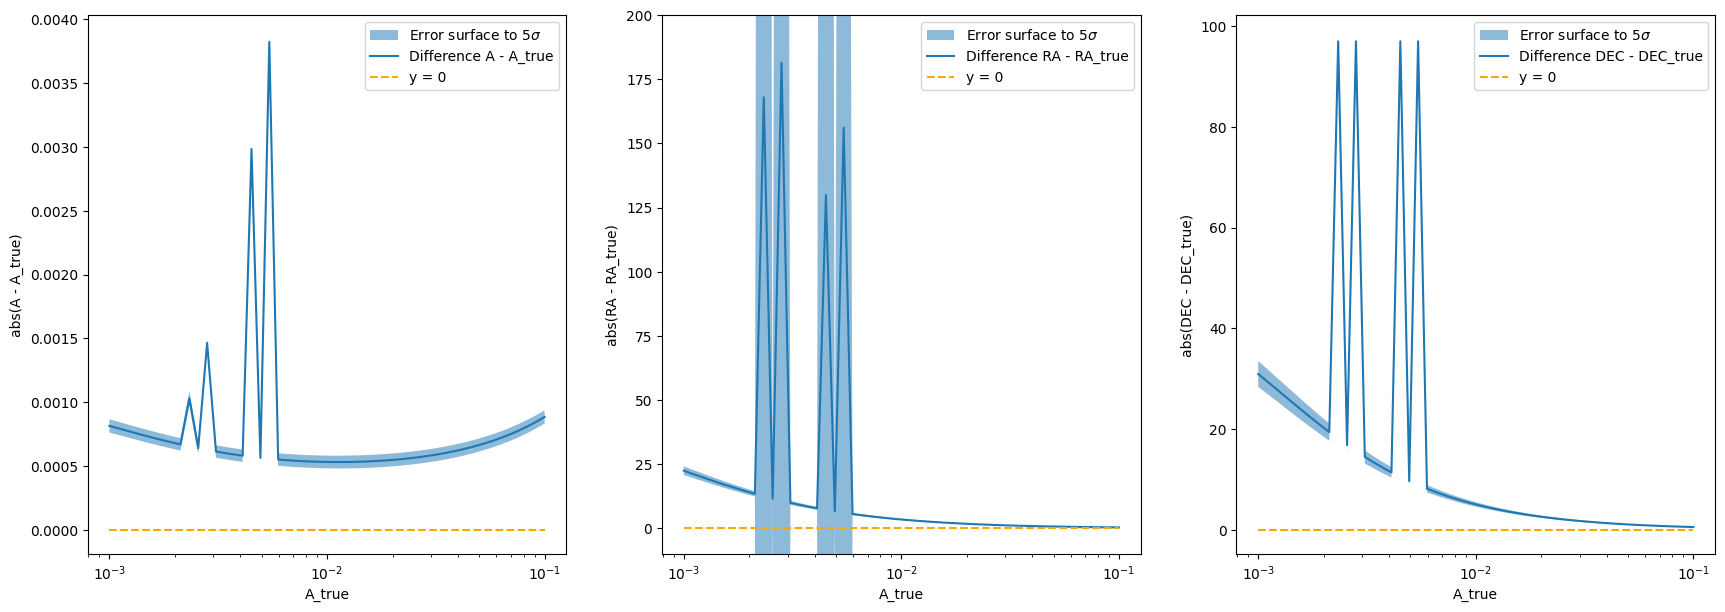

In [18]:
fig, ax = plt.subplots(1, 3, figsize=(3*7,7))
compareFit_diff(dfMinuit_filtered, "A", "A", nsigma=5, figax=(fig, ax[0]))
compareFit_diff(dfMinuit_filtered, "A", "ra", ylegend="RA", nsigma=5, figax=(fig, ax[1]))
compareFit_diff(dfMinuit_filtered, "A", "dec", ylegend="DEC", nsigma=5, figax=(fig, ax[2]))
ax[1].set_ylim([-10, 200])  #used for band u
#ax[1].set_ylim([-10, 130]) #used for band i

clSuffix_Clust = f"Cluster_band_{band}"
output_path = "Simul_Figures/Simul_Magnitude/Simul_Magnitude_ParamStudy/"
output_path_Clust = f"{output_path}Simul_Magnitude_ParamStudy_Cluster/Simul_Magnitude_ParamStudy_{clSuffix_Clust}/"
sufix = f"m5_A_study_diffARaDec_{clSuffix_Clust}"
get_savefig(plt, output_path_Clust, sufix)

Saving m5_A_study_ratioARaDec_Cluster_band_u in Simul_Figures/Simul_Magnitude/Simul_Magnitude_ParamStudy/Simul_Magnitude_ParamStudy_Cluster/Simul_Magnitude_ParamStudy_Cluster_band_u/m5_A_study_ratioARaDec_Cluster_band_u.pdf


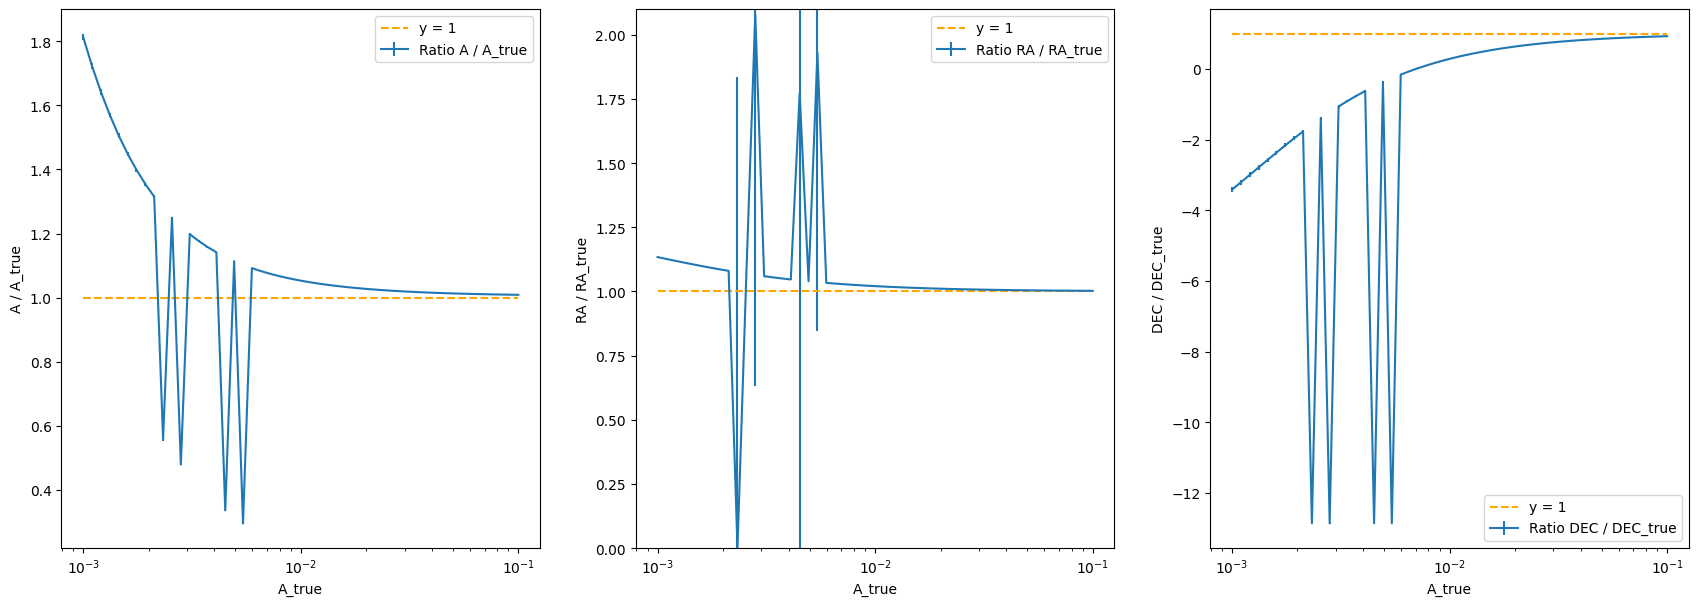

In [24]:
fig, ax = plt.subplots(1, 3, figsize=(3*7,7))
compareFit_ratio(dfMinuit_filtered, "A", "A", nsigma=2, figax=(fig, ax[0]), surface=False)
compareFit_ratio(dfMinuit_filtered, "A", "ra", ylegend="RA", nsigma=2, figax=(fig, ax[1]), surface=False)
compareFit_ratio(dfMinuit_filtered, "A", "dec", ylegend="DEC", nsigma=2, figax=(fig, ax[2]), surface=False)
#ax[0].legend(loc="lower right")
ax[2].legend(loc="lower right")
#ax[1].set_ylim([0.3, 2]) #used for band i
ax[1].set_ylim([0, 2.1]) #used for band u

sufix = f"m5_A_study_ratioARaDec_{clSuffix_Clust}"
get_savefig(plt, output_path_Clust, sufix)